In [1]:
# Cell 0: Install (usually not needed) and imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

RNG = np.random.default_rng(42)


In [2]:
# Cell 1: Bundle metadata
bundle = {
    "bundle_name": "Humble Tech Book Bundle: Data Science by No Starch Press",
    "publisher": "No Starch Press",
    "bundle_year": 2023,
    "currency": "GBP",  # we'll model UK revenue in GBP
    "tiers": {
        "TIER_10": {
            "price_floor_gbp": 10,
            "books": [
                "Doing Math with Python",
                "Math Adventures with Python",
                "Statistics Done Wrong",
                "Data Visualization with JavaScript",
                "The Book of F#"
            ],
        },
        "TIER_18": {
            "price_floor_gbp": 18,
            "books": [
                "Python Flash Cards",
                "The Art of R Programming",
                "The Book of R",
                "Bayesian Statistics the Fun Way",
                "Mining Social Media",
            ],
        },
        "TIER_36": {
            "price_floor_gbp": 36,
            "books": [
                "Dive Into Data Science",
                "Modeling and Simulation in Python",
                "MySQL Crash Course",
                "Practical SQL, 2nd Edition",
                "Python for Data Science",
                "Python Tools for Scientists",
                "The Book of Dash",
                "The Shape of Data",
            ],
        },
    },
    "notes": "Tier contents described in public posts; exact Humble page may expire after campaign ends."
}

bundle


{'bundle_name': 'Humble Tech Book Bundle: Data Science by No Starch Press',
 'publisher': 'No Starch Press',
 'bundle_year': 2023,
 'currency': 'GBP',
 'tiers': {'TIER_10': {'price_floor_gbp': 10,
   'books': ['Doing Math with Python',
    'Math Adventures with Python',
    'Statistics Done Wrong',
    'Data Visualization with JavaScript',
    'The Book of F#']},
  'TIER_18': {'price_floor_gbp': 18,
   'books': ['Python Flash Cards',
    'The Art of R Programming',
    'The Book of R',
    'Bayesian Statistics the Fun Way',
    'Mining Social Media']},
  'TIER_36': {'price_floor_gbp': 36,
   'books': ['Dive Into Data Science',
    'Modeling and Simulation in Python',
    'MySQL Crash Course',
    'Practical SQL, 2nd Edition',
    'Python for Data Science',
    'Python Tools for Scientists',
    'The Book of Dash',
    'The Shape of Data']}},
 'notes': 'Tier contents described in public posts; exact Humble page may expire after campaign ends.'}

In [3]:
# Cell 2: Book catalog from tiers
rows = []
for tier, info in bundle["tiers"].items():
    for title in info["books"]:
        rows.append({
            "bundle_name": bundle["bundle_name"],
            "tier": tier,
            "tier_price_floor_gbp": info["price_floor_gbp"],
            "title": title
        })

catalog_df = pd.DataFrame(rows).drop_duplicates().sort_values(["tier_price_floor_gbp", "title"])
catalog_df.reset_index(drop=True, inplace=True)
catalog_df


,bundle_name,tier,tier_price_floor_gbp,title
0,Humble Tech Book Bundle: Data Science by No St...,TIER_10,10,Data Visualization with JavaScript
1,Humble Tech Book Bundle: Data Science by No St...,TIER_10,10,Doing Math with Python
2,Humble Tech Book Bundle: Data Science by No St...,TIER_10,10,Math Adventures with Python
3,Humble Tech Book Bundle: Data Science by No St...,TIER_10,10,Statistics Done Wrong
4,Humble Tech Book Bundle: Data Science by No St...,TIER_10,10,The Book of F#
5,Humble Tech Book Bundle: Data Science by No St...,TIER_18,18,Bayesian Statistics the Fun Way
6,Humble Tech Book Bundle: Data Science by No St...,TIER_18,18,Mining Social Media
7,Humble Tech Book Bundle: Data Science by No St...,TIER_18,18,Python Flash Cards
8,Humble Tech Book Bundle: Data Science by No St...,TIER_18,18,The Art of R Programming
9,Humble Tech Book Bundle: Data Science by No St...,TIER_18,18,The Book of R


In [4]:
# Cell 3: Synthetic dataset generator

def make_date_range(start="2023-11-01", end="2023-12-23"):
    return pd.date_range(start=start, end=end, freq="D")

DATES = make_date_range()

regions = ["Manchester", "Rest_of_UK"]
channels = ["Humble_Direct", "Amazon", "Indie_Bookshop", "Other_Online"]
formats = ["Digital", "Print"]

age_bands = ["16-24", "25-34", "35-44", "45-54", "55+"]
customer_segments = ["Student", "Early_Career", "Mid_Career", "Senior", "Hobbyist"]
income_bands = ["<20k", "20-35k", "35-50k", "50-75k", "75k+"]

tier_keys = list(bundle["tiers"].keys())

def seasonal_spike(d):
    # simulate marketing spike near launch and near end date
    # launch effect (first week)
    launch = (d - pd.Timestamp("2023-11-01")).days
    end = (pd.Timestamp("2023-12-23") - d).days
    launch_boost = np.exp(-launch/6) * 1.4
    end_boost = np.exp(-end/6) * 1.2
    return 1 + launch_boost + end_boost

def generate_sales(n_rows=12000):
    out = []
    for _ in range(n_rows):
        d = RNG.choice(DATES)

        # region weighting: Rest_of_UK bigger than Manchester
        region = RNG.choice(regions, p=[0.12, 0.88])

        # channel mix: Humble dominates bundle purchases, others reflect spillover/secondary sales
        channel = RNG.choice(channels, p=[0.72, 0.14, 0.08, 0.06])

        # format mix differs by channel
        if channel == "Humble_Direct":
            fmt = RNG.choice(formats, p=[0.97, 0.03])
        elif channel == "Amazon":
            fmt = RNG.choice(formats, p=[0.55, 0.45])
        else:
            fmt = RNG.choice(formats, p=[0.35, 0.65])

        tier = RNG.choice(tier_keys, p=[0.40, 0.35, 0.25])  # typical tier distribution
        floor_price = bundle["tiers"][tier]["price_floor_gbp"]

        # units per transaction line (usually 1 bundle, sometimes multiples)
        base_units = RNG.choice([1,1,1,2,3], p=[0.78,0.08,0.06,0.06,0.02])

        # demand level with time spikes and region factor
        demand = seasonal_spike(d)
        region_factor = 1.25 if region == "Manchester" else 1.0

        # convert demand into units, with noise
        units = max(1, int(np.round(base_units * demand * region_factor * RNG.uniform(0.7, 1.3))))

        # pricing model:
        # - Humble is pay-what-you-want above floor; model avg paid above floor
        # - Other channels sell individual books; approximate AOV (average order value)
        if channel == "Humble_Direct":
            paid_multiplier = RNG.uniform(1.0, 1.6)  # how much above floor people pay
            gross_revenue = units * floor_price * paid_multiplier
        else:
            # approximate per-book price print/digital
            if fmt == "Digital":
                gross_revenue = units * RNG.uniform(10, 22)
            else:
                gross_revenue = units * RNG.uniform(18, 35)

        # simple cost model (COGS + platform fees):
        # - digital: low marginal cost but platform fees
        # - print: higher unit cost + returns risk
        if fmt == "Digital":
            cogs = gross_revenue * RNG.uniform(0.08, 0.18)
        else:
            cogs = units * RNG.uniform(4.0, 9.0) + gross_revenue * RNG.uniform(0.10, 0.18)

        # profit
        profit = gross_revenue - cogs

        # customer descriptors
        age = RNG.choice(age_bands, p=[0.18, 0.38, 0.22, 0.14, 0.08])
        seg = RNG.choice(customer_segments, p=[0.22, 0.28, 0.24, 0.10, 0.16])
        inc = RNG.choice(income_bands, p=[0.18, 0.30, 0.26, 0.18, 0.08])

        out.append({
            "date": d,
            "region": region,
            "channel": channel,
            "format": fmt,
            "tier": tier if channel == "Humble_Direct" else "N/A",
            "units": units,
            "gross_revenue_gbp": round(gross_revenue, 2),
            "cogs_fees_gbp": round(cogs, 2),
            "profit_gbp": round(profit, 2),
            "customer_age_band": age,
            "customer_segment": seg,
            "customer_income_band": inc,
        })

    return pd.DataFrame(out)

sales_df = generate_sales(n_rows=16000)

sales_df.head(), sales_df.shape


(        date      region        channel   format     tier  units  gross_revenue_gbp  cogs_fees_gbp  profit_gbp customer_age_band  \
 0 2023-11-05  Rest_of_UK         Amazon    Print      N/A      4             125.45          35.63       89.82             25-34   
 1 2023-12-12  Rest_of_UK  Humble_Direct  Digital  TIER_18      1              24.82           3.87       20.95             25-34   
 2 2023-12-06  Rest_of_UK  Humble_Direct  Digital  TIER_10      1              15.81           1.78       14.03             25-34   
 3 2023-12-12  Rest_of_UK  Humble_Direct  Digital  TIER_18      1              25.56           2.84       22.72             45-54   
 4 2023-12-18  Rest_of_UK  Humble_Direct  Digital  TIER_10      2              28.46           4.50       23.96             25-34   
 
   customer_segment customer_income_band  
 0         Hobbyist               35-50k  
 1         Hobbyist               50-75k  
 2     Early_Career               20-35k  
 3           Senior         

In [5]:
# Cell 4: Basic checks
sales_df.isna().sum()


date                    0
region                  0
channel                 0
format                  0
tier                    0
units                   0
gross_revenue_gbp       0
cogs_fees_gbp           0
profit_gbp              0
customer_age_band       0
customer_segment        0
customer_income_band    0
dtype: int64

In [6]:
# Cell 5: Basic sanity summary
sales_df[["units", "gross_revenue_gbp", "cogs_fees_gbp", "profit_gbp"]].describe()


,units,gross_revenue_gbp,cogs_fees_gbp,profit_gbp
count,16000.000000,16000.000000,16000.000000,16000.000000
mean,1.451250,35.231626,6.302219,28.929416
std,0.784482,28.309661,6.493607,24.200077
min,1.000000,10.000000,0.800000,0.570000
25%,1.000000,18.327500,2.250000,13.700000
50%,1.000000,26.280000,4.010000,21.210000
75%,2.000000,44.650000,8.150000,37.020000
max,11.000000,518.650000,82.000000,461.180000


In [7]:
# Cell 6: Total units sold
units_by_region = sales_df.groupby("region")["units"].sum().sort_values(ascending=False)
units_by_region


region
Rest_of_UK    19888
Manchester     3332
Name: units, dtype: int64

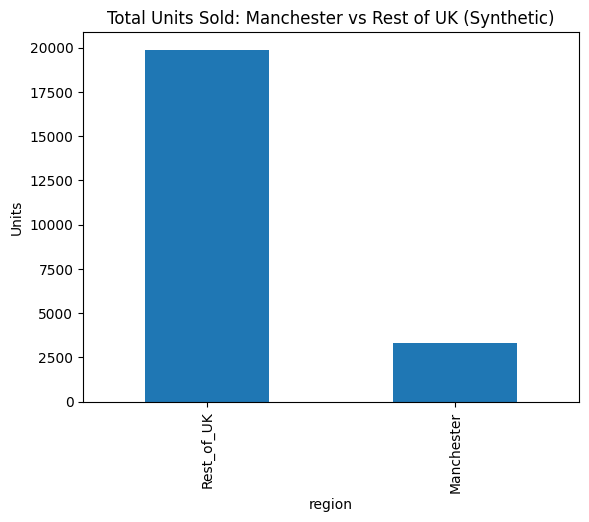

In [8]:
# Cell 7: Plot
units_by_region.plot(kind="bar")
plt.title("Total Units Sold: Manchester vs Rest of UK (Synthetic)")
plt.ylabel("Units")
plt.show()


In [9]:
# Cell 8: Daily units trend by region
daily_units = (sales_df.groupby(["date", "region"])["units"].sum()
               .reset_index()
               .pivot(index="date", columns="region", values="units")
               .fillna(0))

daily_units.head()


region,Manchester,Rest_of_UK
date,,
2023-11-01,106,738
2023-11-02,97,585
2023-11-03,91,574
2023-11-04,77,508
2023-11-05,69,478


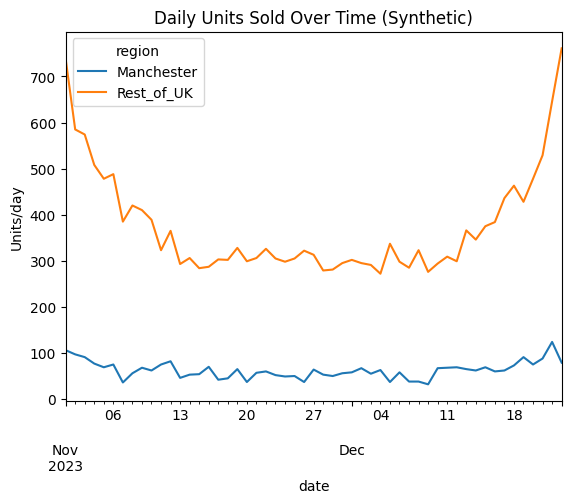

In [10]:
# Cell 9: Plot daily trend
daily_units.plot()
plt.title("Daily Units Sold Over Time (Synthetic)")
plt.ylabel("Units/day")
plt.show()


In [11]:
# Cell 10: Weekly rollup (velocity over time)
sales_df["week"] = sales_df["date"].dt.to_period("W").astype(str)

weekly_units = (sales_df.groupby(["week", "region"])["units"].sum()
                .reset_index()
                .pivot(index="week", columns="region", values="units")
                .fillna(0))

weekly_units.head()


region,Manchester,Rest_of_UK
week,,
2023-10-30/2023-11-05,440,2883
2023-11-06/2023-11-12,454,2780
2023-11-13/2023-11-19,375,2103
2023-11-20/2023-11-26,342,2161
2023-11-27/2023-12-03,403,2056


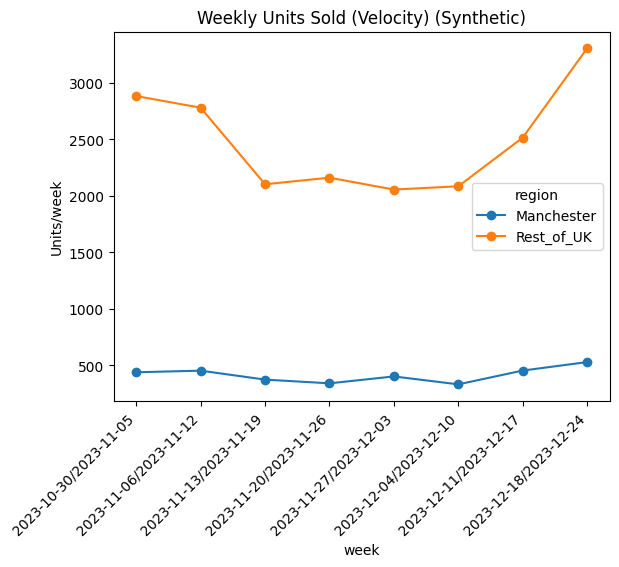

In [12]:
# Cell 11: Weekly plot
weekly_units.plot(kind="line", marker="o")
plt.title("Weekly Units Sold (Velocity) (Synthetic)")
plt.ylabel("Units/week")
plt.xticks(rotation=45, ha="right")
plt.show()


In [13]:
# Cell 12: Format breakdown by region
format_mix = (sales_df.groupby(["region", "format"])["units"].sum()
              .reset_index()
              .sort_values(["region", "units"], ascending=[True, False]))
format_mix


,region,format,units
0,Manchester,Digital,2732
1,Manchester,Print,600
2,Rest_of_UK,Digital,16403
3,Rest_of_UK,Print,3485


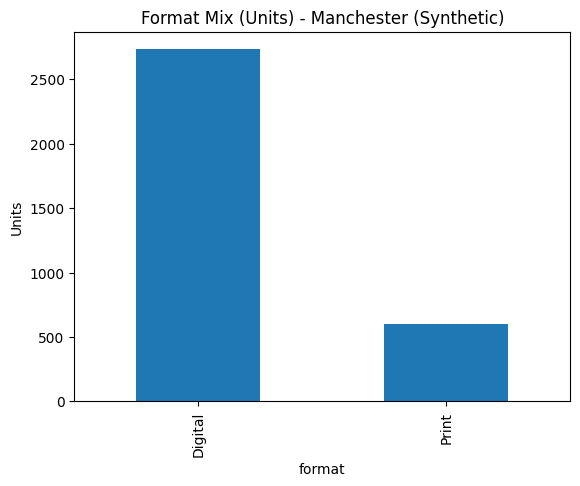

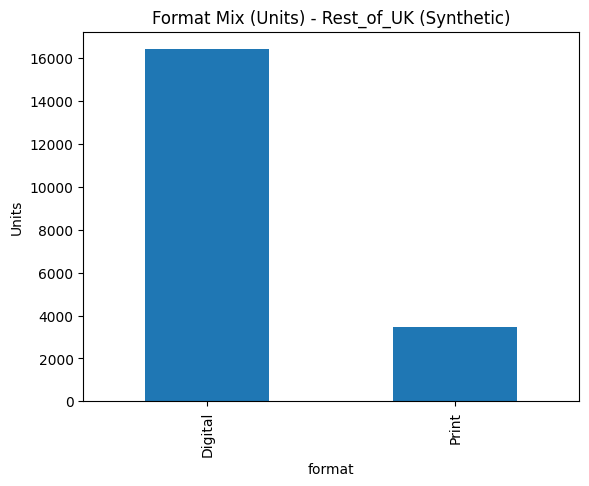

In [14]:
# Cell 13: Plot
for r in regions:
    tmp = format_mix[format_mix["region"] == r].set_index("format")["units"]
    tmp.plot(kind="bar")
    plt.title(f"Format Mix (Units) - {r} (Synthetic)")
    plt.ylabel("Units")
    plt.show()


In [15]:
# Cell 14: Channel mix
channel_mix = (sales_df.groupby(["region", "channel"])["units"].sum()
               .reset_index()
               .sort_values(["region", "units"], ascending=[True, False]))
channel_mix


,region,channel,units
1,Manchester,Humble_Direct,2374
0,Manchester,Amazon,495
2,Manchester,Indie_Bookshop,276
3,Manchester,Other_Online,187
5,Rest_of_UK,Humble_Direct,14418
4,Rest_of_UK,Amazon,2727
6,Rest_of_UK,Indie_Bookshop,1559
7,Rest_of_UK,Other_Online,1184


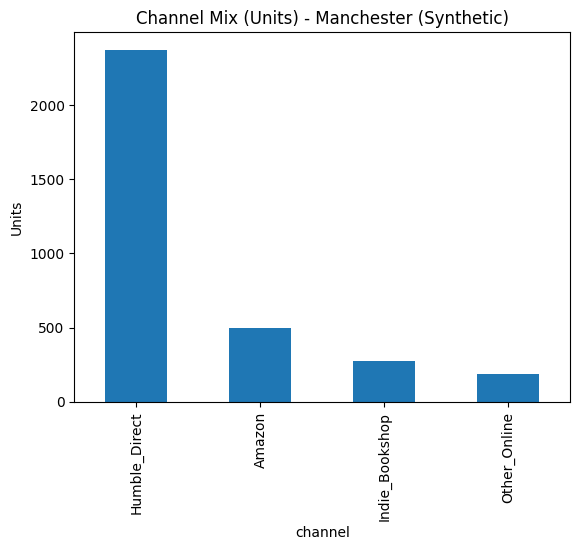

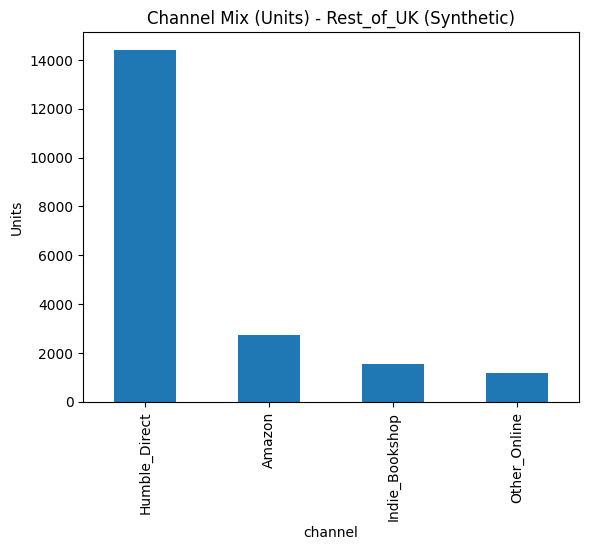

In [16]:
# Cell 15: Plot channel mix
for r in regions:
    tmp = channel_mix[channel_mix["region"] == r].set_index("channel")["units"]
    tmp.plot(kind="bar")
    plt.title(f"Channel Mix (Units) - {r} (Synthetic)")
    plt.ylabel("Units")
    plt.show()


In [17]:
# Cell 16: Geographic share
geo_share = (sales_df.groupby("region")["units"].sum() / sales_df["units"].sum()).sort_values(ascending=False)
geo_share


region
Rest_of_UK    0.856503
Manchester    0.143497
Name: units, dtype: float64

In [18]:
# Cell 17: Top spike days (all UK) and by region
top_days_all = sales_df.groupby("date")["units"].sum().sort_values(ascending=False).head(10)
top_days_mcr = sales_df[sales_df["region"]=="Manchester"].groupby("date")["units"].sum().sort_values(ascending=False).head(10)
top_days_uk = sales_df[sales_df["region"]=="Rest_of_UK"].groupby("date")["units"].sum().sort_values(ascending=False).head(10)

top_days_all, top_days_mcr, top_days_uk


(date
 2023-11-01    844
 2023-12-23    840
 2023-12-22    770
 2023-11-02    682
 2023-11-03    665
 2023-12-21    617
 2023-11-04    585
 2023-11-06    563
 2023-12-20    553
 2023-11-05    547
 Name: units, dtype: int64,
 date
 2023-12-22    124
 2023-11-01    106
 2023-11-02     97
 2023-11-03     91
 2023-12-19     91
 2023-12-21     88
 2023-11-12     82
 2023-12-23     79
 2023-11-04     77
 2023-11-11     75
 Name: units, dtype: int64,
 date
 2023-12-23    761
 2023-11-01    738
 2023-12-22    646
 2023-11-02    585
 2023-11-03    574
 2023-12-21    529
 2023-11-04    508
 2023-11-06    488
 2023-11-05    478
 2023-12-20    478
 Name: units, dtype: int64)

In [19]:
# Cell 18: Weekly revenue/profit by region
weekly_fin = (sales_df.groupby(["week", "region"])[["gross_revenue_gbp", "profit_gbp"]].sum()
              .reset_index()
              .pivot(index="week", columns="region", values=["gross_revenue_gbp", "profit_gbp"])
              .fillna(0))

weekly_fin.head()


gross_revenue_gbp            profit_gbp           
region                       Manchester Rest_of_UK Manchester Rest_of_UK
week                                                                    
2023-10-30/2023-11-05          10180.87   71063.05    8410.68   57999.51
2023-11-06/2023-11-12          10458.82   65556.50    8547.95   53924.96
2023-11-13/2023-11-19           8449.46   51476.98    6900.28   42374.26
2023-11-20/2023-11-26           8313.25   52920.14    6728.86   43738.54
2023-11-27/2023-12-03           9215.15   50226.29    7531.26   41412.68

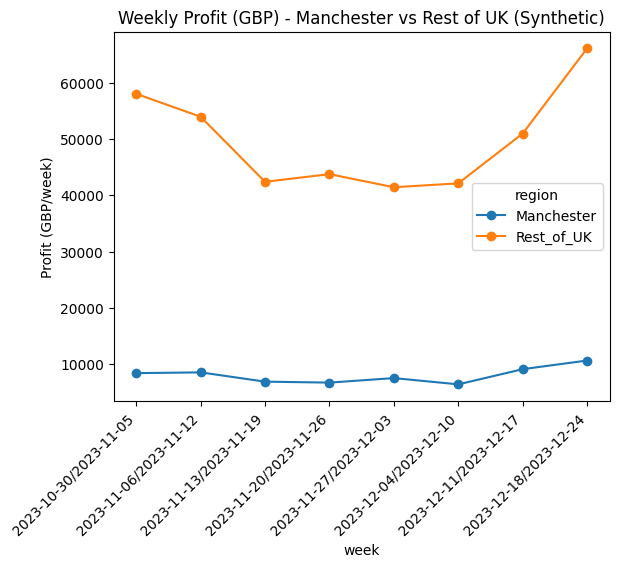

In [20]:
# Cell 19: Plot weekly profit
weekly_fin["profit_gbp"].plot(kind="line", marker="o")
plt.title("Weekly Profit (GBP) - Manchester vs Rest of UK (Synthetic)")
plt.ylabel("Profit (GBP/week)")
plt.xticks(rotation=45, ha="right")
plt.show()


In [21]:
# Cell 20: Annualized estimate
# If your dataset covers only the campaign window, "yearly" here means "annualized run-rate",
# not literal full-year historical actuals.

days_covered = (sales_df["date"].max() - sales_df["date"].min()).days + 1
annualize_factor = 365 / days_covered

annualized = (sales_df.groupby("region")[["units","gross_revenue_gbp","profit_gbp"]].sum() * annualize_factor).round(2)
annualized.rename(columns={
    "units": "annualized_units",
    "gross_revenue_gbp": "annualized_revenue_gbp",
    "profit_gbp": "annualized_profit_gbp"
}, inplace=True)

days_covered, annualize_factor, annualized


(53,
 6.886792452830188,
             annualized_units  annualized_revenue_gbp  annualized_profit_gbp
 region                                                                     
 Manchester          22946.79               542682.07              442839.21
 Rest_of_UK         136964.53              3339444.30             2744854.89)

In [22]:
# Cell 21: Segment mix by region
seg_mix = (sales_df.groupby(["region", "customer_segment"])["units"].sum()
           .reset_index()
           .sort_values(["region","units"], ascending=[True, False]))
seg_mix


,region,customer_segment,units
0,Manchester,Early_Career,943
2,Manchester,Mid_Career,836
4,Manchester,Student,728
1,Manchester,Hobbyist,521
3,Manchester,Senior,304
5,Rest_of_UK,Early_Career,5581
7,Rest_of_UK,Mid_Career,4689
9,Rest_of_UK,Student,4485
6,Rest_of_UK,Hobbyist,3177
8,Rest_of_UK,Senior,1956


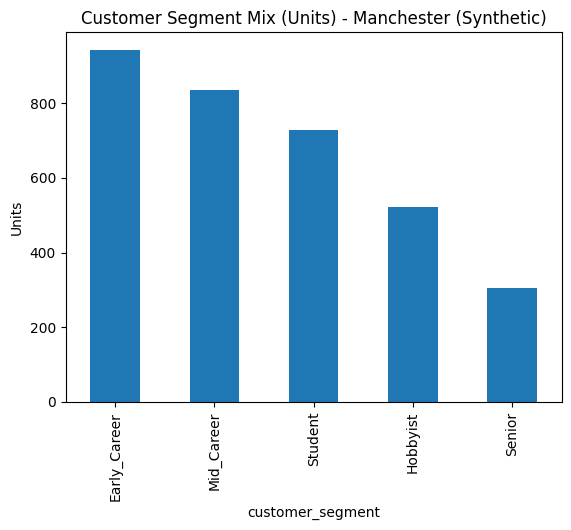

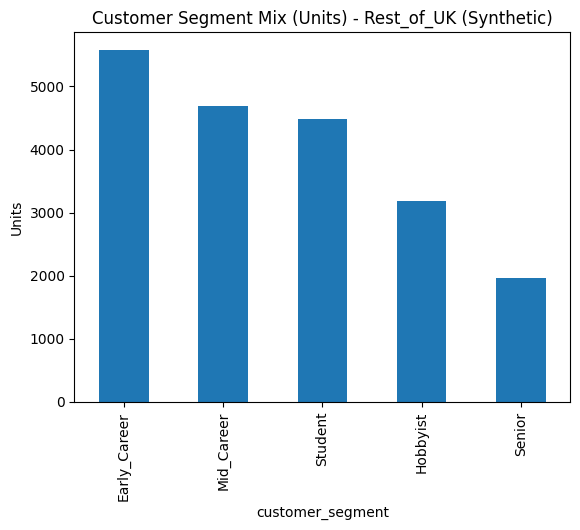

In [23]:
# Cell 22: Plot segment mix
for r in regions:
    tmp = seg_mix[seg_mix["region"] == r].set_index("customer_segment")["units"]
    tmp.plot(kind="bar")
    plt.title(f"Customer Segment Mix (Units) - {r} (Synthetic)")
    plt.ylabel("Units")
    plt.show()


In [24]:
# Cell 23: Age band mix
age_mix = (sales_df.groupby(["region", "customer_age_band"])["units"].sum()
           .reset_index()
           .sort_values(["region","units"], ascending=[True, False]))
age_mix


,region,customer_age_band,units
1,Manchester,25-34,1215
2,Manchester,35-44,786
0,Manchester,16-24,583
3,Manchester,45-54,466
4,Manchester,55+,282
6,Rest_of_UK,25-34,7442
7,Rest_of_UK,35-44,4356
5,Rest_of_UK,16-24,3498
8,Rest_of_UK,45-54,2988
9,Rest_of_UK,55+,1604


In [25]:
# Cell 24: Income band mix
income_mix = (sales_df.groupby(["region", "customer_income_band"])["units"].sum()
              .reset_index()
              .sort_values(["region","units"], ascending=[True, False]))
income_mix


,region,customer_income_band,units
0,Manchester,20-35k,1000
1,Manchester,35-50k,831
4,Manchester,<20k,623
2,Manchester,50-75k,621
3,Manchester,75k+,257
5,Rest_of_UK,20-35k,5870
6,Rest_of_UK,35-50k,5218
9,Rest_of_UK,<20k,3673
7,Rest_of_UK,50-75k,3570
8,Rest_of_UK,75k+,1557


In [26]:
# Cell 25: Unit economics by channel and format
unit_econ = (sales_df.groupby(["region","channel","format"])
             .agg(units=("units","sum"),
                  revenue=("gross_revenue_gbp","sum"),
                  profit=("profit_gbp","sum"))
             .reset_index())

unit_econ["profit_margin"] = (unit_econ["profit"] / unit_econ["revenue"]).replace([np.inf,-np.inf], np.nan)
unit_econ.sort_values(["region","profit"], ascending=[True, False]).head(20)


,region,channel,format,units,revenue,profit,profit_margin
2,Manchester,Humble_Direct,Digital,2315,56561.85,49129.59,0.868599
1,Manchester,Amazon,Print,243,6446.66,3867.89,0.599984
0,Manchester,Amazon,Digital,252,4050.62,3509.22,0.866341
5,Manchester,Indie_Bookshop,Print,173,4714.00,2932.43,0.622068
7,Manchester,Other_Online,Print,125,3107.88,1855.15,0.596918
4,Manchester,Indie_Bookshop,Digital,103,1694.44,1470.70,0.867956
3,Manchester,Humble_Direct,Print,59,1362.12,791.04,0.580742
6,Manchester,Other_Online,Digital,62,862.84,746.66,0.865352
10,Rest_of_UK,Humble_Direct,Digital,13983,354683.91,308684.69,0.870309
9,Rest_of_UK,Amazon,Print,1266,33462.40,20673.89,0.617824


In [27]:
# Cell 26: Which channels are most profitable per unit?
unit_econ["profit_per_unit"] = unit_econ["profit"] / unit_econ["units"]
unit_econ.sort_values(["region","profit_per_unit"], ascending=[True, False]).head(20)


,region,channel,format,units,revenue,profit,profit_margin,profit_per_unit
2,Manchester,Humble_Direct,Digital,2315,56561.85,49129.59,0.868599,21.222285
5,Manchester,Indie_Bookshop,Print,173,4714.00,2932.43,0.622068,16.950462
1,Manchester,Amazon,Print,243,6446.66,3867.89,0.599984,15.917243
7,Manchester,Other_Online,Print,125,3107.88,1855.15,0.596918,14.841200
4,Manchester,Indie_Bookshop,Digital,103,1694.44,1470.70,0.867956,14.278641
0,Manchester,Amazon,Digital,252,4050.62,3509.22,0.866341,13.925476
3,Manchester,Humble_Direct,Print,59,1362.12,791.04,0.580742,13.407458
6,Manchester,Other_Online,Digital,62,862.84,746.66,0.865352,12.042903
10,Rest_of_UK,Humble_Direct,Digital,13983,354683.91,308684.69,0.870309,22.075713
13,Rest_of_UK,Indie_Bookshop,Print,1023,27178.28,16783.83,0.617546,16.406481


In [28]:
# Cell 27: Checklist mapping
checklist = pd.DataFrame([
    ["Total Units Sold", "Sum(units) by title/region/channel", "sales_df.groupby(...)['units'].sum()"],
    ["Sales Trends Over Time", "Daily/weekly units; spikes near promos", "daily_units / weekly_units"],
    ["Format Breakdown", "Digital vs Print mix", "groupby(['format'])"],
    ["Retailer vs Direct Sales", "Channel mix: Humble vs Amazon vs Indie", "groupby(['channel'])"],
    ["Geographic Distribution", "Manchester vs Rest_of_UK (or borough)", "groupby(['region'])"],
    ["Rate of Sale (Velocity)", "Units/day or units/week", "resample or groupby week"],
    ["Revenue Generated", "Sum revenue; after discounts/returns proxy", "gross_revenue_gbp, profit_gbp"],
    ["Reviews & Sentiment", "Join external reviews dataset later", "merge on title/ISBN"],
    ["Benchmarks (~3k lifetime sales)", "Compare cumulative units to benchmark", "cumulative sums"],
    ["First Edition identification", "Collector meta fields if relevant", "add number_line field"]
], columns=["Metric","How","Notebook pointer"])

checklist


,Metric,How,Notebook pointer
0,Total Units Sold,Sum(units) by title/region/channel,sales_df.groupby(...)['units'].sum()
1,Sales Trends Over Time,Daily/weekly units; spikes near promos,daily_units / weekly_units
2,Format Breakdown,Digital vs Print mix,groupby(['format'])
3,Retailer vs Direct Sales,Channel mix: Humble vs Amazon vs Indie,groupby(['channel'])
4,Geographic Distribution,Manchester vs Rest_of_UK (or borough),groupby(['region'])
5,Rate of Sale (Velocity),Units/day or units/week,resample or groupby week
6,Revenue Generated,Sum revenue; after discounts/returns proxy,"gross_revenue_gbp, profit_gbp"
7,Reviews & Sentiment,Join external reviews dataset later,merge on title/ISBN
8,Benchmarks (~3k lifetime sales),Compare cumulative units to benchmark,cumulative sums
9,First Edition identification,Collector meta fields if relevant,add number_line field


In [29]:
# Cell 28: Export synthetic dataset + catalog
sales_df.to_csv("humble_datasci_sales_synthetic_uk.csv", index=False)
catalog_df.to_csv("humble_datasci_bundle_catalog.csv", index=False)

print("Wrote:")
print(" - humble_datasci_sales_synthetic_uk.csv")
print(" - humble_datasci_bundle_catalog.csv")


Wrote:
 - humble_datasci_sales_synthetic_uk.csv
 - humble_datasci_bundle_catalog.csv
